In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
from scipy.stats import skew
from scipy.stats import f_oneway, chi2_contingency
from google.colab import files
warnings.filterwarnings('ignore')

In [2]:
# Load station offence metrucs from File 2

df = pd.read_csv('station_offence_metrics.csv')
print(f"Loaded {df['station_code'].nunique()} stations")
print(df.head())

Loaded 564 stations
   station_code station_name station_division          county  \
0         11101   Bailieboro   Cavan/Monaghan  Cavan/Monaghan   
1         11101   Bailieboro   Cavan/Monaghan  Cavan/Monaghan   
2         11101   Bailieboro   Cavan/Monaghan  Cavan/Monaghan   
3         11101   Bailieboro   Cavan/Monaghan  Cavan/Monaghan   
4         11101   Bailieboro   Cavan/Monaghan  Cavan/Monaghan   

                                  offence_group_name  incidents_hist  \
0  Attempts/threats to murder, assaults, harassme...             143   
1                      Burglary and related offences              88   
2                           Controlled drug offences              97   
3  Damage to property and to the environment  off...             157   
4                        Dangerous or negligent acts             177   

   incidents_recent  incidents_total_all_years  growth_abs  growth_rate  \
0               180                       7452          37     0.258741   
1     

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   station_code               7896 non-null   int64  
 1   station_name               7896 non-null   object 
 2   station_division           7896 non-null   object 
 3   county                     7896 non-null   object 
 4   offence_group_name         7896 non-null   object 
 5   incidents_hist             7896 non-null   int64  
 6   incidents_recent           7896 non-null   int64  
 7   incidents_total_all_years  7896 non-null   int64  
 8   growth_abs                 7896 non-null   int64  
 9   growth_rate                7147 non-null   float64
 10  new_activity_flag          7896 non-null   bool   
 11  growth_ratio_capped        7147 non-null   float64
dtypes: bool(1), float64(2), int64(5), object(4)
memory usage: 686.4+ KB


In [4]:
df.shape

(7896, 12)

In [5]:
df.describe()

,station_code,incidents_hist,incidents_recent,incidents_total_all_years,growth_abs,growth_rate,growth_ratio_capped
count,7896.000000,7896.000000,7896.000000,7896.000000,7896.000000,7147.000000,7147.000000
mean,35875.046099,200.517351,180.535714,13793.402482,-19.981636,0.349636,1.327413
std,25369.960150,778.483304,656.333037,28302.840062,245.449617,1.583902,1.321584
min,11101.000000,0.000000,0.000000,144.000000,-7898.000000,-1.000000,0.000000
25%,23102.750000,5.000000,6.000000,1511.250000,-11.000000,-0.360000,0.640000
50%,34104.500000,24.000000,24.000000,3311.500000,0.000000,0.000000,1.000000
75%,51104.250000,104.000000,96.000000,11055.250000,8.000000,0.500000,1.500000
max,512015.000000,26906.000000,20580.000000,258096.000000,5574.000000,46.076923,10.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
station_code,0
station_name,0
station_division,0
county,0
offence_group_name,0
incidents_hist,0
incidents_recent,0
incidents_total_all_years,0
growth_abs,0
growth_rate,749


In [8]:
df['station_code'].nunique()

564

In [9]:
df['station_name'].nunique()

560

In [10]:
df['offence_group_name'].nunique()

14

In [11]:
# Station coverage by division

print(" Station coverage (how stations are distributed across divisions)")

n_stations = df["station_code"].nunique()
n_divisions = df["station_division"].nunique()

print(f"Total Garda stations in dataset: {n_stations}")
print(f"Total Garda divisions in dataset: {n_divisions}")

# Unique stations per division (not row counts)
stations_per_division = (
    df.groupby("station_division")["station_code"]
      .nunique()
      .sort_values(ascending=False)
)

print("\nTop divisions by number of stations:")
display(stations_per_division)



 Station coverage (how stations are distributed across divisions)
Total Garda stations in dataset: 564
Total Garda divisions in dataset: 28

Top divisions by number of stations:


,station_code
station_division,
Galway,46
Donegal,37
Tipperary,37
Cork West,32
Limerick,29
Mayo,29
Kilkenny/Carlow,25
Laois/Offaly,25
Cavan/Monaghan,25


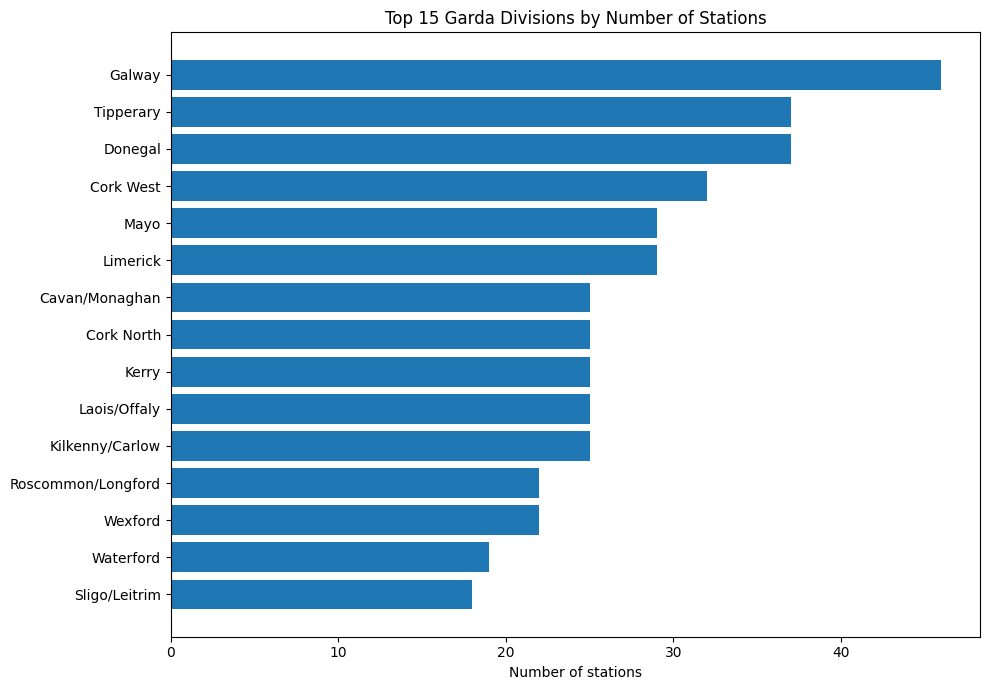

In [12]:
# Visualise: stations per division (top 15 for readability)
top_n = 15
plot_df = stations_per_division.head(top_n).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df.index, plot_df.values)
plt.title(f"Top {top_n} Garda Divisions by Number of Stations")
plt.xlabel("Number of stations")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 📊 National Offence Distribution (2020–2024)

Before segmenting stations, we first examine which offence groups dominate nationally.

This provides context on:
- The overall crime structure across Ireland
- Whether workload is concentrated in specific offence categories
- How offence composition may influence station-level clustering

The following table shows the top offence groups ranked by total recent incidents (2020–2024).

In [13]:
# Offence dominance
print("TOP OFFENCES (Recent Incidents 2020–2024):")

offence_vol = (
    df.groupby('offence_group_name')['incidents_recent']
      .sum()
      .sort_values(ascending=False)
)

display(offence_vol.head(10))

TOP OFFENCES (Recent Incidents 2020–2024):


,incidents_recent
offence_group_name,
Theft and related offences,313916
Road and traffic offences,246996
Dangerous or negligent acts,176077
Public order and other social code offences,164626
"Attempts/threats to murder, assaults, harassments and related offences",111895
Damage to property and to the environment offences,105066
Controlled drug offences,93715
"Offences against government, justice procedures and organisation of crime",70428
"Fraud, deception and related offences",59779


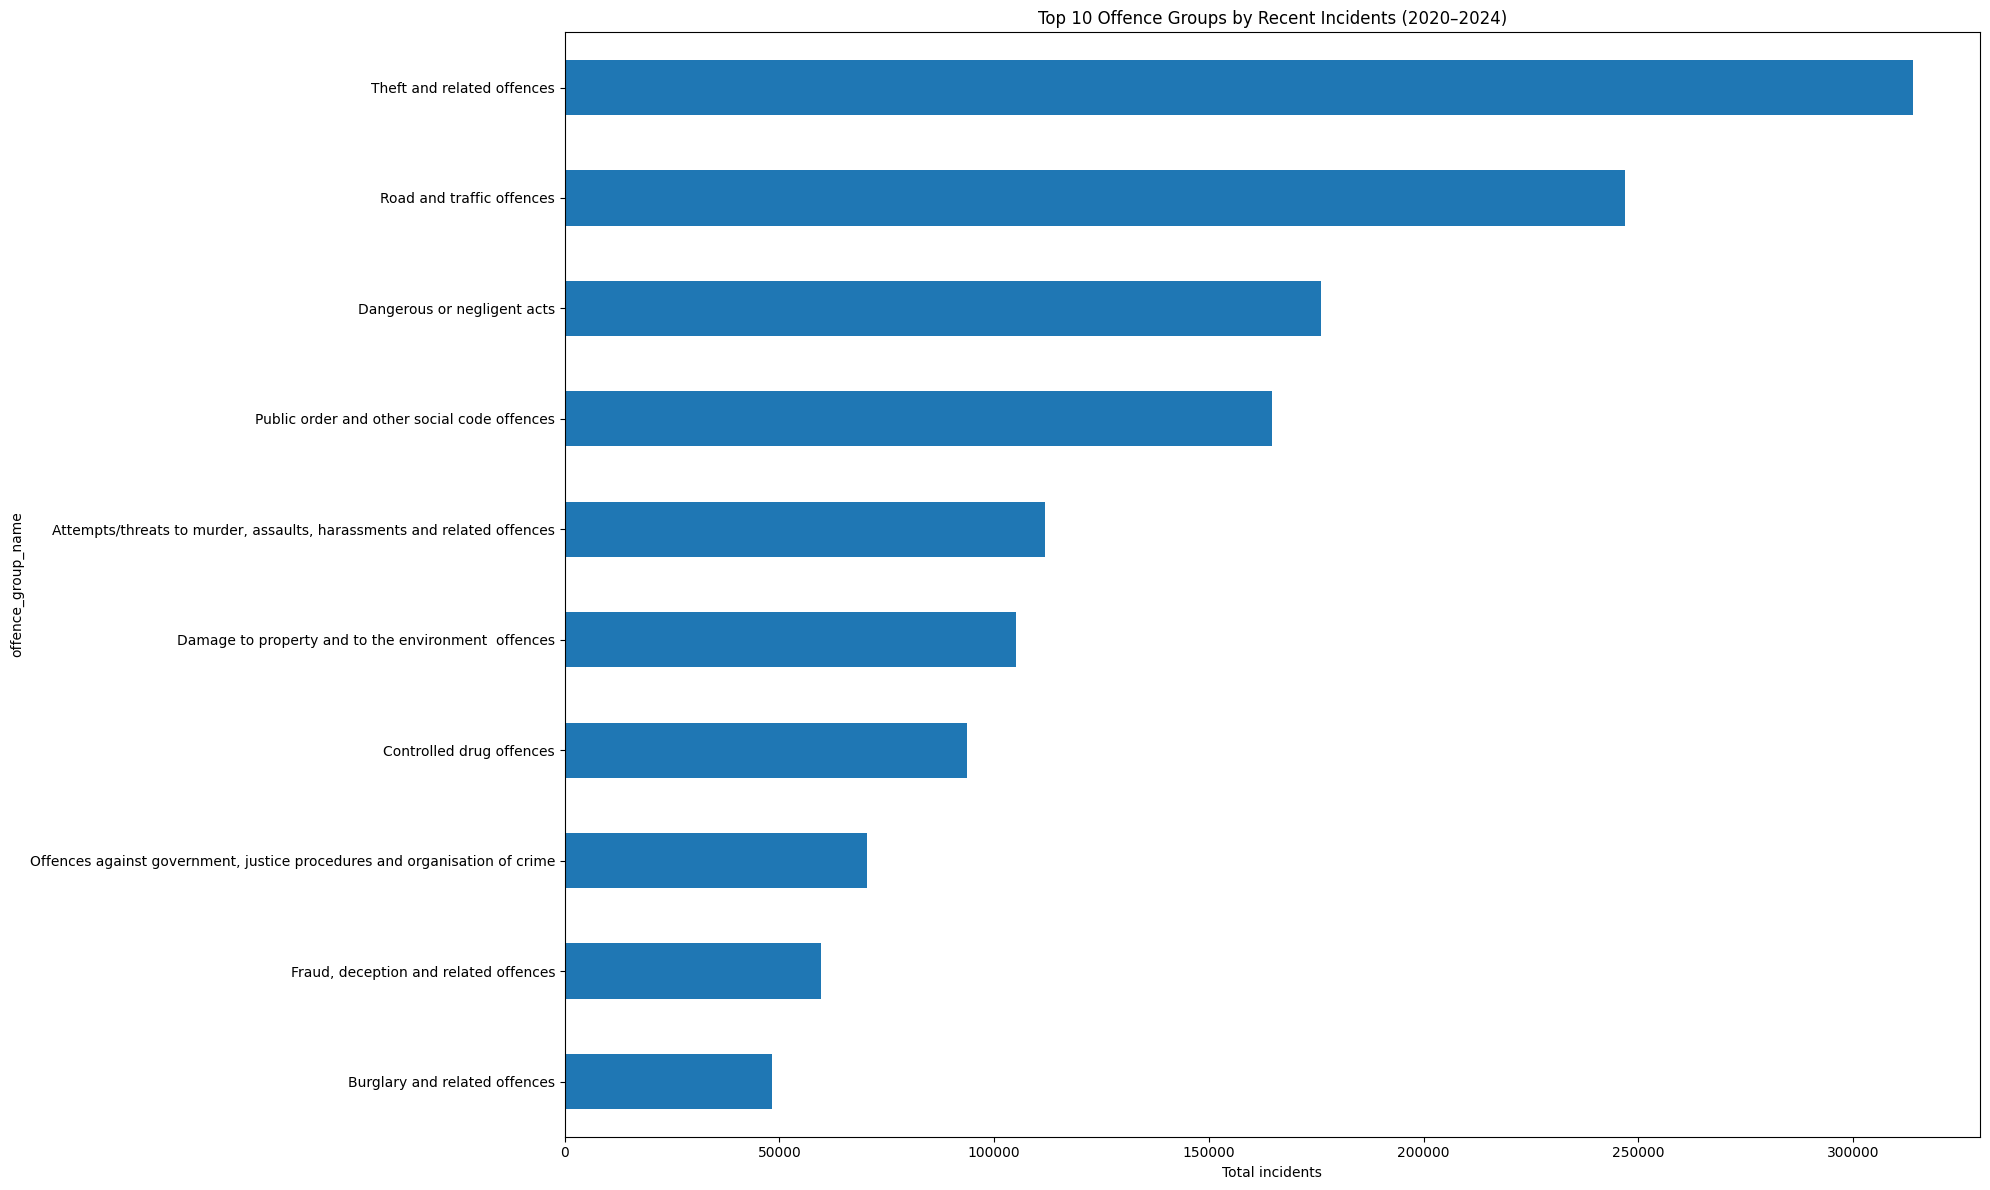

In [14]:
plt.figure(figsize=(20, 12))
offence_vol.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Offence Groups by Recent Incidents (2020–2024)")
plt.xlabel("Total incidents")
plt.tight_layout()
plt.show()

## 📈 Growth Dynamics (Recent vs Historical)

Before clustering stations, we examine overall growth behaviour across station × offence combinations.

Key questions:
- Is growth widespread or concentrated?
- Are there extreme outliers?
- How many stations show strong upward trajectory?
- How common is new offence activity?

The statistics below summarise offence-level growth patterns and station-level growth signals.

In [15]:
# Growth patterns
print("GROWTH SUMMARY:")
print(df['growth_rate'].describe())
print("Stations with growth >50%:", (df.groupby('station_code')['growth_rate'].mean() > 0.5).sum())
print("New activity stations:", df[df['new_activity_flag']]['station_code'].nunique())

GROWTH SUMMARY:
count    7147.000000
mean        0.349636
std         1.583902
min        -1.000000
25%        -0.360000
50%         0.000000
75%         0.500000
max        46.076923
Name: growth_rate, dtype: float64
Stations with growth >50%: 153
New activity stations: 263


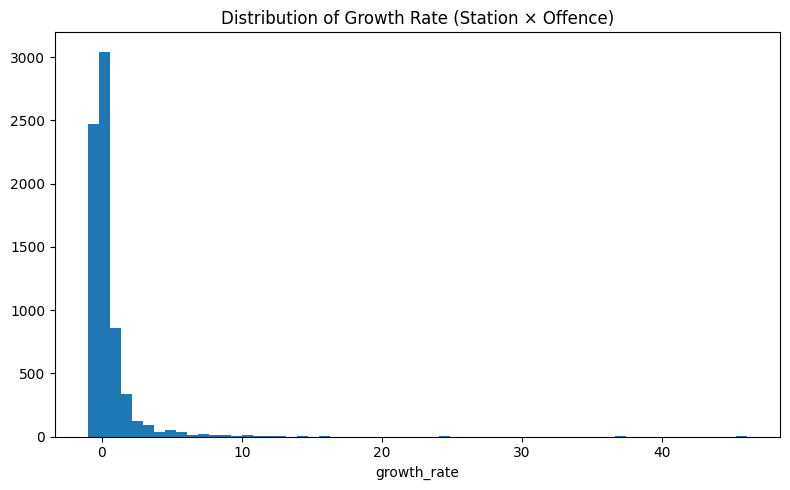

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['growth_rate'], bins=60)
plt.title("Distribution of Growth Rate (Station × Offence)")
plt.xlabel("growth_rate")
plt.tight_layout()
plt.show()

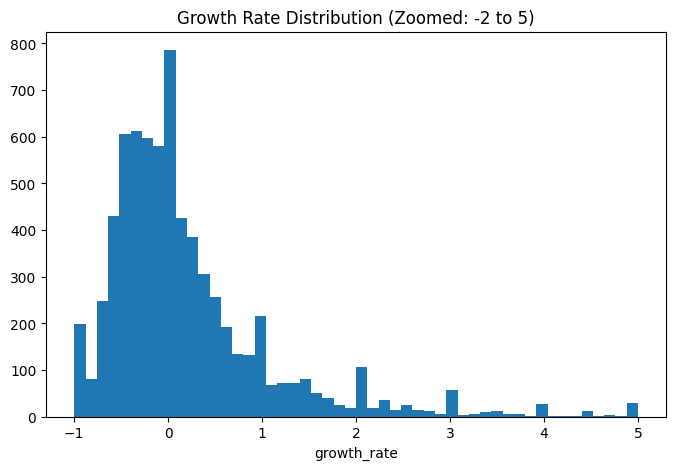

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df[df['growth_rate'].between(-2,5)]['growth_rate'], bins=50)
plt.title("Growth Rate Distribution (Zoomed: -2 to 5)")
plt.xlabel("growth_rate")
plt.show()

### 📈 Growth Rate Distribution (Zoomed View: -2 to 5)

The zoomed distribution removes extreme outliers and reveals the true structural pattern of offence-level growth.

Key observations:

- The majority of station × offence growth rates lie between **-0.5 and +1.0**.
- The median growth is approximately **0**, indicating many stable offence categories.
- A visible right tail remains, showing moderate positive growth across several offences.
- Negative values (down to -1) indicate offence reductions in some stations.

Interpretation:

- Growth is not uniformly explosive — it is mostly concentrated in modest ranges.
- Extreme values (>5) seen in the full distribution likely reflect small historical bases rather than structural shifts.
- For clustering, using `growth_ratio_capped` helps stabilise these tail effects while preserving meaningful trajectory signals.

This confirms that growth dynamics are present but must be handled carefully in modelling.

In [18]:
# Missing values snapshot
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top):")
print(missing[missing > 0].head(20))

# Duplicates check (should be 0)
dup = df.duplicated().sum()
print("\nDuplicate rows:", dup)


Missing values (top):
growth_rate            749
growth_ratio_capped    749
dtype: int64

Duplicate rows: 0


## 🧹 Data Quality Checks

Before feature engineering and clustering, we validate dataset integrity.

Key checks performed:
- Confirmed 7,896 rows (564 stations × 14 offence groups).
- Verified 564 unique station codes.
- Verified 14 offence groups per station.
- No duplicate rows detected.

Missing values:

- 749 missing values in `growth_rate` and `growth_ratio_capped`.
- These occur where historical incidents = 0, meaning growth cannot be computed.
- This reflects genuine new offence emergence rather than data errors.

Conclusion:
The dataset structure is complete and consistent.  
Missing growth values represent structural signals and will be handled appropriately during feature engineering.

In [19]:
num_cols = [
    "incidents_hist",
    "incidents_recent",
    "incidents_total_all_years",
    "growth_abs",
    "growth_rate",
    "growth_ratio_capped"
]

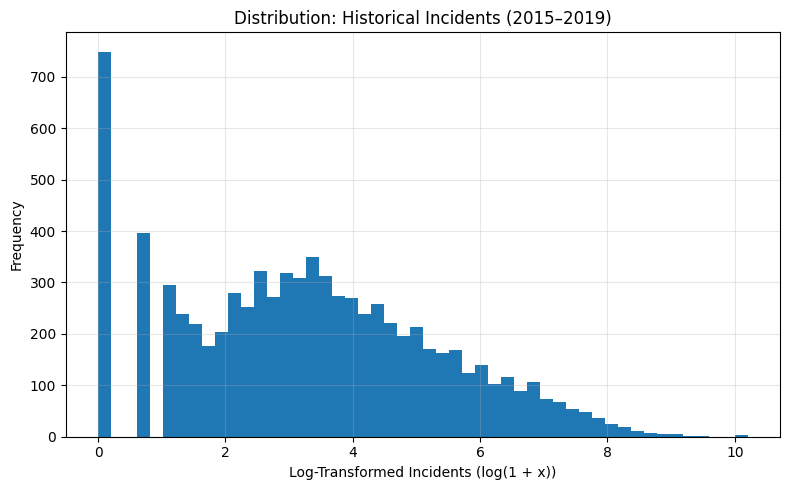

In [20]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["incidents_hist"]), bins=50)
plt.title("Distribution: Historical Incidents (2015–2019)")
plt.xlabel("Log-Transformed Incidents (log(1 + x))")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

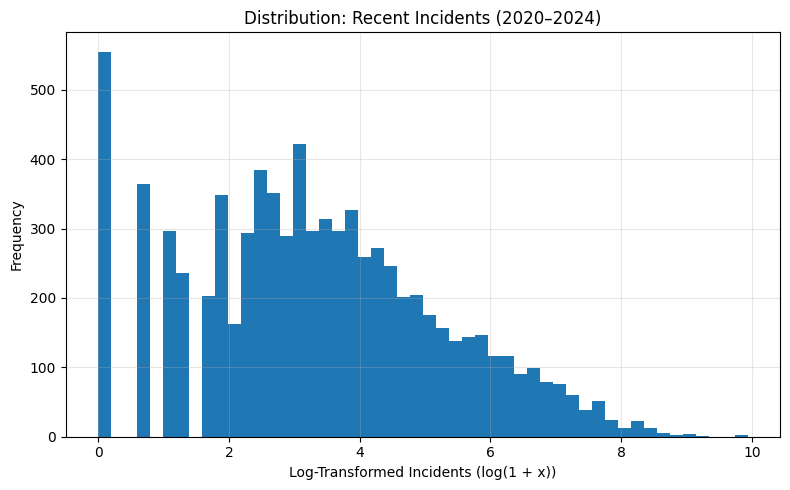

In [21]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["incidents_recent"]), bins=50)
plt.title("Distribution: Recent Incidents (2020–2024)")
plt.xlabel("Log-Transformed Incidents (log(1 + x))")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

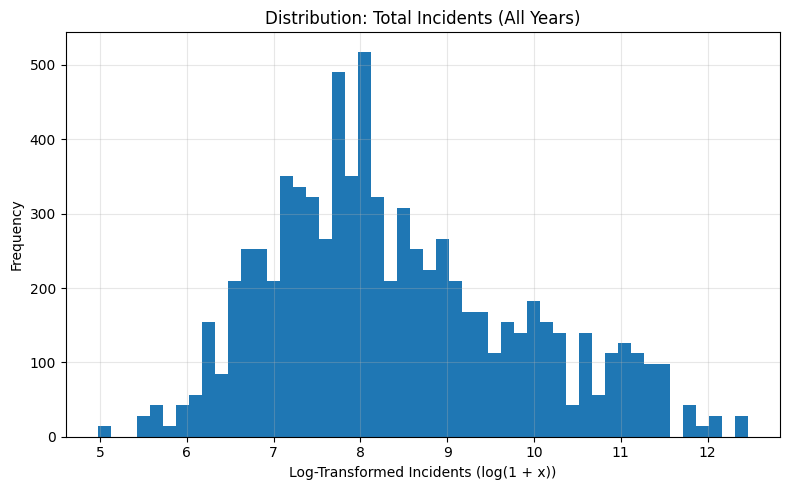

In [22]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["incidents_total_all_years"]), bins=50)
plt.title("Distribution: Total Incidents (All Years)")
plt.xlabel("Log-Transformed Incidents (log(1 + x))")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

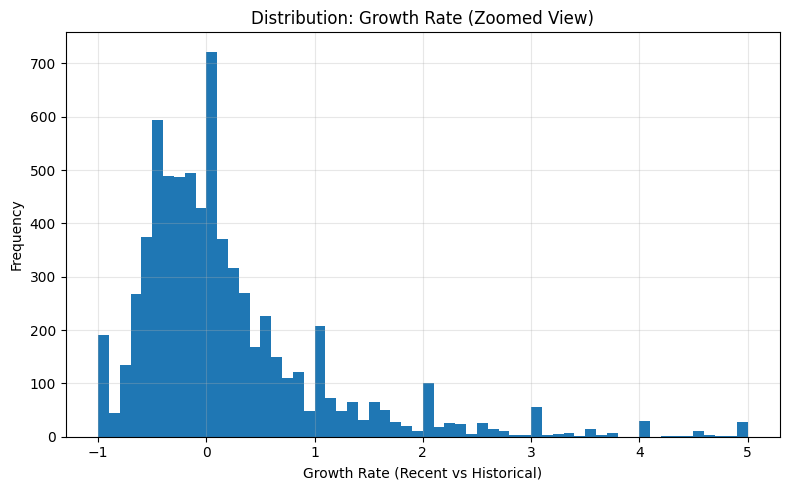

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df[df["growth_rate"].between(-2,5)]["growth_rate"], bins=60)
plt.title("Distribution: Growth Rate (Zoomed View)")
plt.xlabel("Growth Rate (Recent vs Historical)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

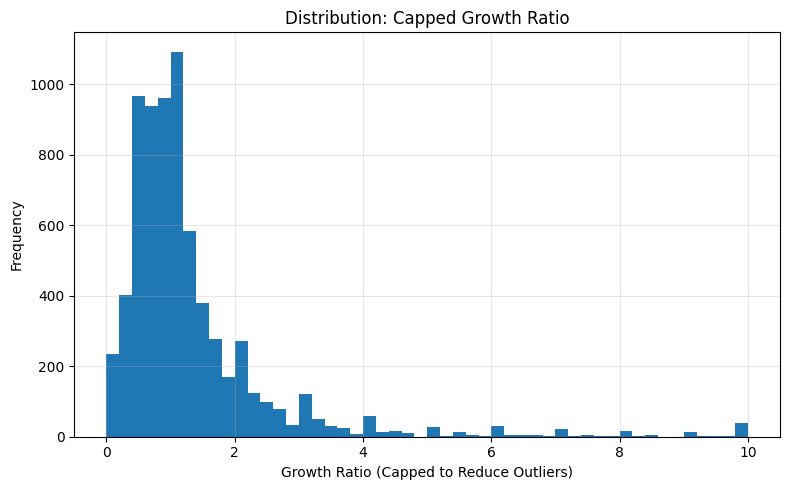

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["growth_ratio_capped"], bins=50)
plt.title("Distribution: Capped Growth Ratio")
plt.xlabel("Growth Ratio (Capped to Reduce Outliers)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## EDA Snapshot — Station × Offence Metrics (2015–2019 vs 2020–2024)

**Dataset size:** 7,896 rows (= 564 stations × 14 offence groups)  
**Columns:** station identifiers + offence group + historical/recent incidents + growth metrics + flags  
**Data quality checks:**
- **Duplicates:** 0
- **Missing values:** `growth_rate` and `growth_ratio_capped` have missing values (expected when historical baseline is 0 and growth is undefined; these are handled via `new_activity_flag` + capped ratios where applicable).

### What the distributions tell us (why we transform / cap)
1) **Incident counts are extremely right-skewed (heavy-tailed).**  
A small number of station×offence combinations carry very high volumes, while most combinations are low volume.  
➡️ This is why **log1p** views are more interpretable and why clustering should use **standardised features** (and often log-volume at station level).

2) **Growth is also skewed with extreme outliers.**  
Most growth values lie in a moderate band (roughly around -1 to +5), but there are rare cases with very high growth due to small historical bases.  
➡️ This is why we prefer:
- a **zoomed growth-rate distribution** for “typical” behaviour, and
- a **capped growth ratio** to prevent tiny historical baselines from dominating the signal.

3) **Interpretation note (important):**  
Growth metrics are *risk/proxy indicators*, not causal measures. Large growth can reflect small baselines, reporting/recording changes, or real increases.  
➡️ In clustering, we combine growth with **volume**, **concentration (HHI)**, **volatility**, and **emerging-count** so the station “fingerprint” is balanced.

### Why this matters for File 3
These shapes confirm the modelling design:
- build station-level features that **separate structural workload** from **emerging change**
- use **StandardScaler** (and optionally log-volume) before KMeans
- validate clusters with **silhouette** + business sanity checks (e.g., workload share by cluster)

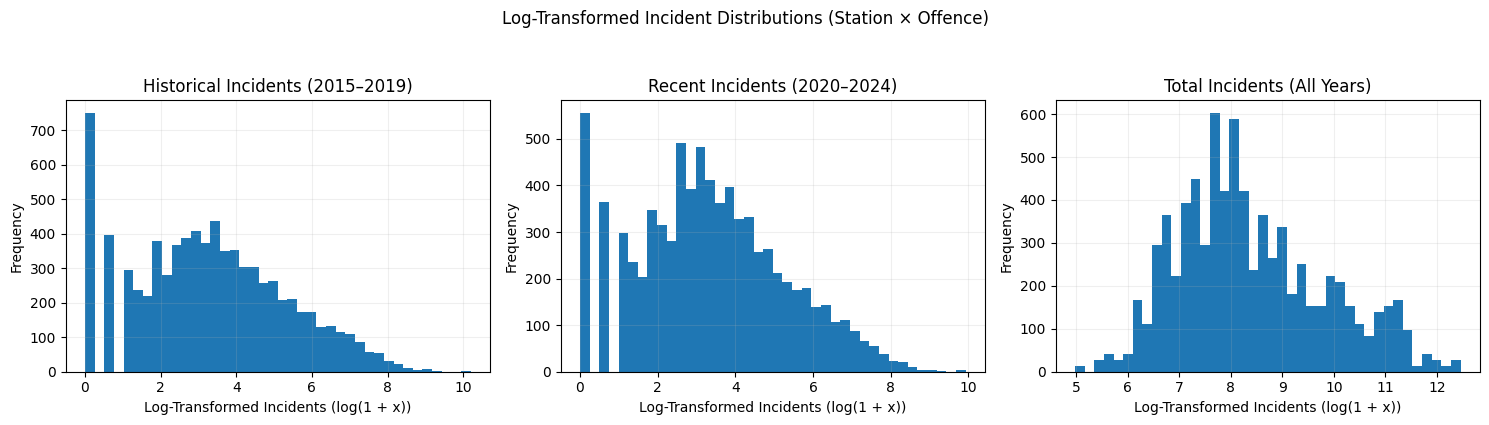

In [25]:
log_cols = [
    ("incidents_hist", "Historical Incidents (2015–2019)"),
    ("incidents_recent", "Recent Incidents (2020–2024)"),
    ("incidents_total_all_years", "Total Incidents (All Years)")
]

plt.figure(figsize=(15, 4))

for i, (col, label) in enumerate(log_cols, 1):
    plt.subplot(1, 3, i)
    plt.hist(np.log1p(df[col]), bins=40)
    plt.title(label)
    plt.xlabel("Log-Transformed Incidents (log(1 + x))")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.2)

plt.suptitle("Log-Transformed Incident Distributions (Station × Offence)", y=1.05)
plt.tight_layout()
plt.show()

## Incident Volume Distributions (Log-Transformed)

The above plots show the distribution of offence-level incident counts across
all station × offence combinations (7,896 rows).

Because raw incident counts are heavily right-skewed (a small number of
station–offence pairs carry very large volumes), we apply a log(1 + x)
transformation to stabilise the distribution while preserving relative scale.

Key observations:

• Incident volumes are strongly right-tailed in raw form, confirming that
  crime workload is unevenly distributed across stations and offence types.

• After log transformation, the distributions become smoother and more
  interpretable, revealing structured variation rather than extreme dominance
  by a few high-volume observations.

• Recent incidents (2020–2024) show a similar structural pattern to historical
  incidents (2015–2019), indicating continuity in workload distribution.

• Total incidents (all years) naturally shift right due to cumulative volume,
  but still exhibit heavy concentration.

Implication for modelling:

Clustering will be performed on station-level aggregated features and
standardised values to prevent high-volume urban stations from dominating
distance calculations.

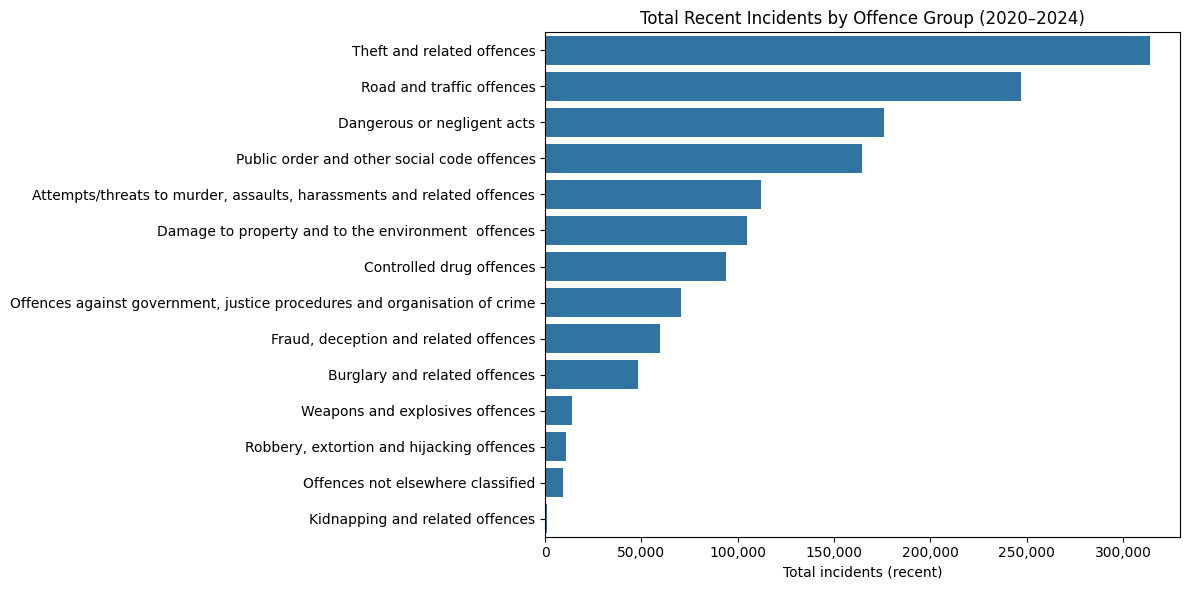

In [26]:
# Offence dominance (national) — Recent period totals
offence_totals_recent = (
    df.groupby("offence_group_name", as_index=False)["incidents_recent"]
      .sum()
      .sort_values("incidents_recent", ascending=False)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=offence_totals_recent,
    y="offence_group_name",
    x="incidents_recent"
)

ax.set_title("Total Recent Incidents by Offence Group (2020–2024)")
ax.set_xlabel("Total incidents (recent)")
ax.set_ylabel("")

# nicer number formatting
ax.xaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")

plt.tight_layout()
plt.show()

## National Offence Mix — Recent Period (2020–2024)

The distribution of recent incidents across offence groups shows a clear structural concentration.

### Key Observations

• **Theft and related offences** are the dominant category nationally, with a substantial lead over all other offence groups.

• **Road and traffic offences** form the second-largest workload component, followed by:
  - Dangerous or negligent acts  
  - Public order and other social code offences  

• There is a visible drop-off after the top 4–5 categories, forming a long tail of lower-volume offence groups such as:
  - Weapons and explosives  
  - Robbery and extortion  
  - Kidnapping and related offences  

### Structural Pattern

The national crime workload is not evenly distributed across offence types.
A small number of offence groups account for the majority of total incidents.

### Implication for File 3 (Clustering)

Because offence volume is concentrated:

• Stations will differ not only by total workload, but by **offence composition**.  
• High-theft stations may cluster together as structural workload hubs.  
• Traffic-dominant stations may form specialised profiles.  
• Low-volume offence categories are unlikely to drive national clustering patterns but may matter locally.

This confirms that offence mix must be incorporated into the station-level feature matrix.

In [27]:
fastest = (
    df.sort_values("growth_ratio_capped", ascending=False)
      .head(10)[[
          "station_name", "station_division", "county",
          "offence_group_name", "incidents_hist", "incidents_recent",
          "growth_abs", "growth_rate", "growth_ratio_capped", "new_activity_flag"
      ]]
)

display(fastest)

,station_name,station_division,county,offence_group_name,incidents_hist,incidents_recent,growth_abs,growth_rate,growth_ratio_capped,new_activity_flag
1069,Grange,Sligo/Leitrim,Sligo/Leitrim,"Fraud, deception and related offences",3,32,29,9.666667,10.0,False
1853,Kiltimagh,Mayo,Mayo,"Fraud, deception and related offences",3,30,27,9.000000,10.0,False
411,Mountcharles,Donegal,Donegal,"Fraud, deception and related offences",1,17,16,16.000000,10.0,False
6285,Killenaule,Tipperary,Tipperary,Weapons and explosives offences,1,13,12,12.000000,10.0,False
2119,Letterfrack,Galway,Galway,"Fraud, deception and related offences",1,13,12,12.000000,10.0,False
4695,Cloghan,Laois/Offaly,Laois/Offaly,"Fraud, deception and related offences",1,14,13,13.000000,10.0,False
495,Clonmany,Donegal,Donegal,"Fraud, deception and related offences",2,23,21,10.500000,10.0,False
3101,Carrigtwohill,Cork North,Cork,"Offences against government, justice procedure...",13,612,599,46.076923,10.0,False
4177,Castlegregory,Kerry,Kerry,"Fraud, deception and related offences",2,22,20,10.000000,10.0,False
4821,Clonaslee,Laois/Offaly,Laois/Offaly,"Fraud, deception and related offences",1,13,12,12.000000,10.0,False


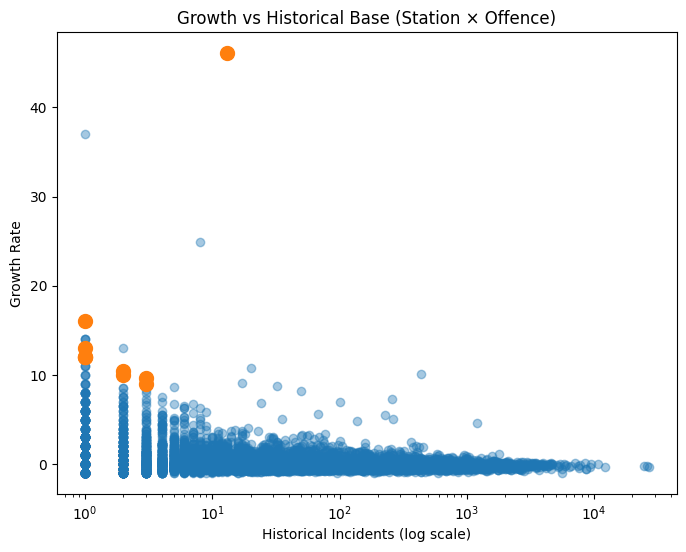

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["incidents_hist"],
    df["growth_rate"],
    alpha=0.4
)

top10_idx = df.sort_values("growth_ratio_capped", ascending=False).head(10).index
plt.scatter(
    df.loc[top10_idx, "incidents_hist"],
    df.loc[top10_idx, "growth_rate"],
    s=100
)

plt.xscale("log")
plt.xlabel("Historical Incidents (log scale)")
plt.ylabel("Growth Rate")
plt.title("Growth vs Historical Base (Station × Offence)")
plt.show()

## Fastest Growing Station × Offence Combinations

This table shows the top 10 station–offence pairs ranked by capped growth ratio.

### Observations
• Fraud-related offences dominate the fastest growth list.
• Many high growth cases start from very small historical bases.
• A few cases (e.g. high absolute increases) indicate structural workload shifts, not just percentage spikes.

### Implication
Growth rate alone can be misleading for small-base offences.
Clustering will therefore combine growth with volume and volatility to avoid distortion.

## Growth vs Historical Base

The relationship shows that extreme growth rates occur almost exclusively at very small historical volumes.

As historical incidents increase, growth stabilises and converges toward zero.

This confirms that percentage growth is highly sensitive to small bases, reinforcing the need to combine growth with workload scale in clustering.

In [29]:
# Station-level totals (564 rows) — clustering base
eps = 1e-6

station_totals = (
    df.groupby(["station_code", "station_name", "station_division", "county"], as_index=False)
      .agg(
          total_recent=("incidents_recent", "sum"),
          total_hist=("incidents_hist", "sum"),
          total_all=("incidents_total_all_years", "sum"),
          emerging_count=("new_activity_flag", lambda x: x.astype(int).sum())
      )
)

station_totals["station_growth_rate"] = (
    (station_totals["total_recent"] - station_totals["total_hist"]) /
    (station_totals["total_hist"] + eps)
)

display(station_totals.head())
print("✅ Station totals rows:", station_totals.shape[0])

,station_code,station_name,station_division,county,total_recent,total_hist,total_all,emerging_count,station_growth_rate
0,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,1234,1439,104328,1,-0.142460
1,11102,Ballyjamesduff,Cavan/Monaghan,Cavan/Monaghan,1218,1440,85148,1,-0.154167
2,11103,Cootehill,Cavan/Monaghan,Cavan/Monaghan,1147,1533,110236,0,-0.251794
3,11104,Kingscourt,Cavan/Monaghan,Cavan/Monaghan,684,765,58352,0,-0.105882
4,11105,Mullagh,Cavan/Monaghan,Cavan/Monaghan,325,604,36526,1,-0.461921


✅ Station totals rows: 564


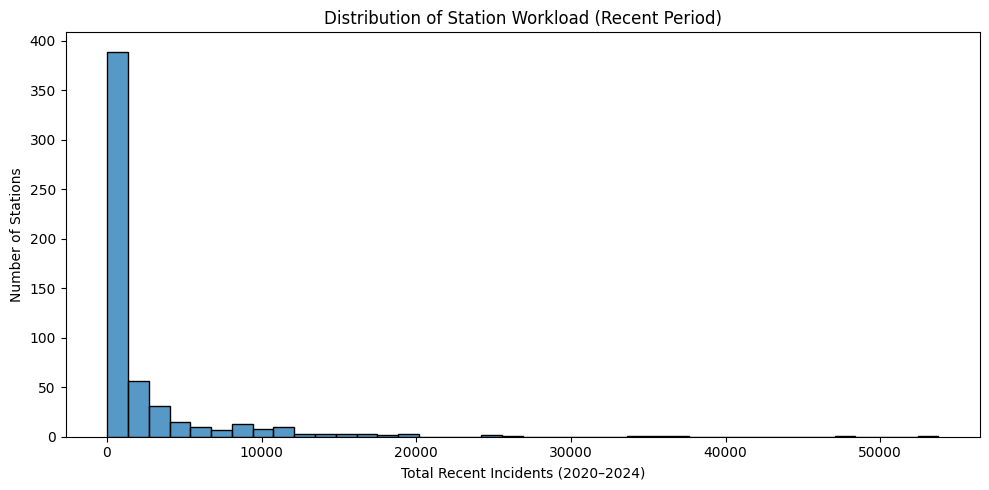

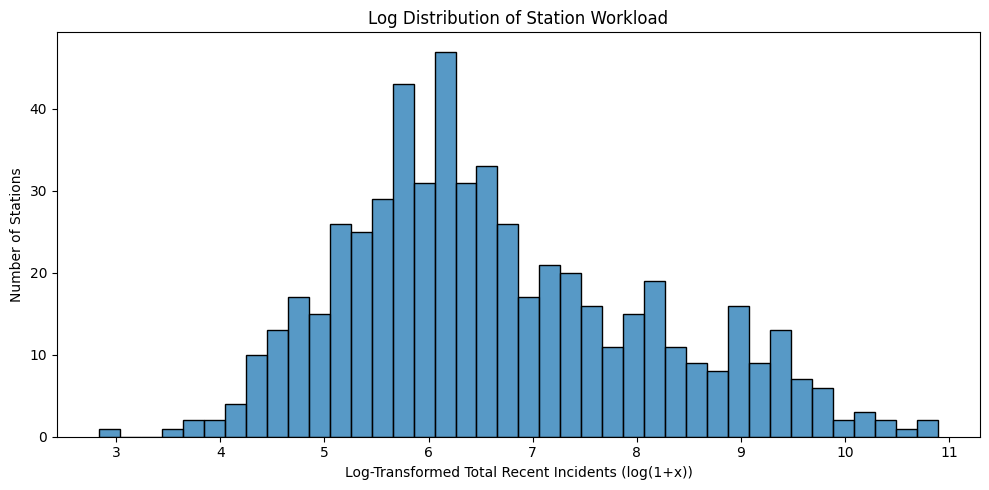

In [30]:
# Station workload distribution
plt.figure(figsize=(10, 5))
sns.histplot(station_totals["total_recent"], bins=40)
plt.xlabel("Total Recent Incidents (2020–2024)")
plt.ylabel("Number of Stations")
plt.title("Distribution of Station Workload (Recent Period)")
plt.tight_layout()
plt.show()

# Log version (better visibility)
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(station_totals["total_recent"]), bins=40)
plt.xlabel("Log-Transformed Total Recent Incidents (log(1+x))")
plt.ylabel("Number of Stations")
plt.title("Log Distribution of Station Workload")
plt.tight_layout()
plt.show()

## Station Workload Distribution (Recent Period)

The raw distribution of total recent incidents is heavily right-skewed.

• Most stations operate at relatively low incident volumes.  
• A small number of stations handle extremely high workloads (long right tail).  
• The difference between low- and high-volume stations is substantial.

The log-transformed view reveals a clearer structural spread across the network, showing that stations are distributed along a workload spectrum rather than forming distinct natural groups.

This confirms:
• Workload scale varies dramatically across stations.  
• Normalisation is required before clustering.  
• A small subset of stations likely drives a large share of national incidents.

## Why We Create `station_features` (and Do Not Modify `df`)

The original dataset `df` contains **7,896 rows**:

- 564 stations  
- 14 offence groups per station  
- Each row represents **station × offence group**

This structure is ideal for offence-level analysis, but it is **not suitable for clustering stations directly**, because:

- Each station appears 14 times  
- Clustering requires **one row per observation**
- Our observation unit for segmentation is the **station**, not the offence

---

## Design Principle

We therefore:

1. Keep `df` unchanged for:
   - Offence-level analysis
   - Drill-down insights
   - Heatmaps and growth patterns

2. Create a new dataset: `station_features`
   - 564 rows (1 per station)
   - Each row summarises the station’s operational structure
   - Used exclusively for clustering

---

## Why This Separation Matters

Keeping the datasets separate ensures:

- Clean analytical design  
- No duplication of station rows  
- Clear distinction between:
  - Offence-level analysis (granular view)
  - Station-level segmentation (strategic view)

This separation improves interpretability and prevents structural errors during clustering.

In [31]:
# One row per station (564 rows)
station_features = (
    df.groupby("station_code", as_index=False)
      .agg(
          station_name=("station_name", "first"),
          station_division=("station_division", "first"),
          county=("county", "first"),
          total_volume_recent=("incidents_recent", "sum"),
          emerging_count=("new_activity_flag", "sum"),
      )
)

print("Station base table:", station_features.shape)
display(station_features.head())

Station base table: (564, 6)


,station_code,station_name,station_division,county,total_volume_recent,emerging_count
0,11101,Bailieboro,Cavan/Monaghan,Cavan/Monaghan,1234,1
1,11102,Ballyjamesduff,Cavan/Monaghan,Cavan/Monaghan,1218,1
2,11103,Cootehill,Cavan/Monaghan,Cavan/Monaghan,1147,0
3,11104,Kingscourt,Cavan/Monaghan,Cavan/Monaghan,684,0
4,11105,Mullagh,Cavan/Monaghan,Cavan/Monaghan,325,1


In [32]:
def calc_hhi(g: pd.DataFrame) -> float:
    """HHI = sum of squared offence shares (recent period).
    0 = diversified, 1 = highly concentrated.
    """
    total = g["incidents_recent"].sum()
    if total <= 0:
        return 0.0
    shares = g["incidents_recent"] / total
    return float((shares ** 2).sum())

def calc_top_share(g: pd.DataFrame) -> float:
    """Largest offence share within the station (recent period)."""
    total = g["incidents_recent"].sum()
    if total <= 0:
        return 0.0
    return float((g["incidents_recent"] / total).max())

hhi_vals = (
    df.groupby("station_code")
      .apply(calc_hhi)
      .reset_index(name="hhi")
)

top_share_vals = (
    df.groupby("station_code")
      .apply(calc_top_share)
      .reset_index(name="top_offence_share")
)

station_features = station_features.merge(hhi_vals, on="station_code", how="left")
station_features = station_features.merge(top_share_vals, on="station_code", how="left")

display(station_features[["station_code", "hhi", "top_offence_share"]].head())

,station_code,hhi,top_offence_share
0,11101,0.116406,0.150729
1,11102,0.150664,0.243021
2,11103,0.169043,0.323452
3,11104,0.118814,0.172515
4,11105,0.134750,0.227692


In [33]:
volatility = (
    df.groupby("station_code")["growth_rate"]
      .std()
      .reset_index(name="growth_volatility")
)

station_features = station_features.merge(volatility, on="station_code", how="left")
station_features["growth_volatility"] = station_features["growth_volatility"].fillna(0)

display(station_features[["station_code", "growth_volatility"]].head())

,station_code,growth_volatility
0,11101,0.762674
1,11102,0.977661
2,11103,0.260803
3,11104,0.683524
4,11105,0.500175


In [34]:
# How many offence groups are active in the recent period?
active_offences = (
    df[df["incidents_recent"] > 0]
      .groupby("station_code")["offence_group_name"]
      .nunique()
      .reset_index(name="num_active_offences")
)

station_features = station_features.merge(active_offences, on="station_code", how="left")
station_features["num_active_offences"] = station_features["num_active_offences"].fillna(0).astype(int)

# What fraction of offence groups have positive growth?
share_growth_positive = (
    df.groupby("station_code")["growth_rate"]
      .apply(lambda s: float((s.dropna() > 0).mean()) if len(s.dropna()) else 0.0)
      .reset_index(name="share_growth_positive")
)

station_features = station_features.merge(share_growth_positive, on="station_code", how="left")

display(station_features[["station_code", "num_active_offences", "share_growth_positive"]].head())

,station_code,num_active_offences,share_growth_positive
0,11101,14,0.307692
1,11102,14,0.461538
2,11103,13,0.384615
3,11104,13,0.714286
4,11105,13,0.307692


In [35]:
eps = 1e-6

# --- Unweighted station growth (totals): (recent - hist) / hist ---
total_hist = df.groupby("station_code")["incidents_hist"].sum()
total_recent = station_features.set_index("station_code")["total_volume_recent"]

station_growth_unweighted = ((total_recent - total_hist) / (total_hist + eps)).fillna(0)

station_features["station_growth_unweighted"] = (
    station_features["station_code"].map(station_growth_unweighted).fillna(0)
)

# --- Risk intensity: volume-weighted growth across offence groups ---
df["_wg"] = df["growth_rate"].fillna(0) * df["incidents_recent"].fillna(0)

risk_intensity = (
    df.groupby("station_code")
      .apply(lambda g: float(g["_wg"].sum() / (g["incidents_recent"].sum() + eps)))
      .reset_index(name="risk_intensity")
)

station_features = station_features.merge(risk_intensity, on="station_code", how="left")
station_features["risk_intensity"] = station_features["risk_intensity"].fillna(0)

display(station_features[["station_code", "station_growth_unweighted", "risk_intensity"]].head())

,station_code,station_growth_unweighted,risk_intensity
0,11101,-0.142460,0.067600
1,11102,-0.154167,0.087775
2,11103,-0.251794,-0.197190
3,11104,-0.105882,0.153586
4,11105,-0.461921,-0.257469


In [36]:
# Not used in clustering; only for sanity checking profiles
station_features["urban_flag"] = (
    station_features["station_division"]
    .str.contains("D.M.R.", case=False, na=False)
    .astype(int)
)

cluster_features = [
    "total_volume_recent",
    "station_growth_unweighted",   # main growth metric
    "hhi",
    "growth_volatility",
    "emerging_count",
    "top_offence_share",
    "num_active_offences",
    "share_growth_positive",
    "risk_intensity"
]

print("✅ Station feature matrix ready \n")
print("Rows, cols:", station_features.shape)
print("Clustering features:", cluster_features )
print("\n")
display(station_features[["station_code"] + cluster_features + ["urban_flag"]].head())

✅ Station feature matrix ready 

Rows, cols: (564, 14)
Clustering features: ['total_volume_recent', 'station_growth_unweighted', 'hhi', 'growth_volatility', 'emerging_count', 'top_offence_share', 'num_active_offences', 'share_growth_positive', 'risk_intensity']




,station_code,total_volume_recent,station_growth_unweighted,hhi,growth_volatility,emerging_count,top_offence_share,num_active_offences,share_growth_positive,risk_intensity,urban_flag
0,11101,1234,-0.142460,0.116406,0.762674,1,0.150729,14,0.307692,0.067600,0
1,11102,1218,-0.154167,0.150664,0.977661,1,0.243021,14,0.461538,0.087775,0
2,11103,1147,-0.251794,0.169043,0.260803,0,0.323452,13,0.384615,-0.197190,0
3,11104,684,-0.105882,0.118814,0.683524,0,0.172515,13,0.714286,0.153586,0
4,11105,325,-0.461921,0.134750,0.500175,1,0.227692,13,0.307692,-0.257469,0


In [37]:
print(cluster_features)

['total_volume_recent', 'station_growth_unweighted', 'hhi', 'growth_volatility', 'emerging_count', 'top_offence_share', 'num_active_offences', 'share_growth_positive', 'risk_intensity']


## 📊 Station Feature Design — What We Built & Why

To perform clustering, we transformed the station × offence dataset (7,896 rows) into a station-level feature matrix (564 rows).

Each station is represented as an operational “fingerprint” capturing workload scale, growth dynamics, and offence structure.

---

### 1️⃣ total_volume_recent  
**Definition:** Sum of incidents (2020–2024)  
**Purpose:** Captures workload scale.  
High values indicate structural workload hubs.

---

### 2️⃣ station_growth_unweighted  
**Definition:** (Recent − Historical) / Historical  
**Purpose:** Measures overall station trajectory.  
Positive values indicate increasing demand pressure.

---

### 3️⃣ hhi (Offence Concentration Index)  
**Definition:** Sum of squared offence shares (recent period).  
**Interpretation:**  
- Low → diversified crime mix  
- High (>0.4) → specialised dominance  
**Purpose:** Identifies structural dependency on few offence types.

---

### 4️⃣ growth_volatility  
**Definition:** Standard deviation of offence-level growth rates.  
**Purpose:** Detects uneven structural change across offence groups.

---

### 5️⃣ emerging_count  
**Definition:** Number of offence groups with new recent activity.  
**Purpose:** Flags structural shifts in local crime patterns.

---

### 6️⃣ top_offence_share  
**Definition:** Largest single offence share within station.  
**Purpose:** Measures single-crime dominance risk.

---

### 7️⃣ num_active_offences  
**Definition:** Count of offence groups with non-zero recent incidents.  
**Purpose:** Captures operational breadth.

---

### 8️⃣ share_growth_positive  
**Definition:** Proportion of offence groups with positive growth.  
**Purpose:** Identifies systemic upward momentum.

---

### 9️⃣ risk_intensity  
**Definition:** Volume-weighted growth rate.  
**Purpose:** Combines scale and trajectory into a pressure signal.

---

## 🎯 Why These Features Matter

Together, these features capture:

- Scale (How large is the workload?)
- Direction (Is demand growing or declining?)
- Structure (Diversified vs specialised crime mix)
- Stability (Volatile vs steady patterns)
- Momentum (Broad growth vs isolated spikes)

This enables segmentation of 564 stations into structural strategy profiles such as:

- Urban Workhorses  
- Growth Watch  
- Stable Baseline  
- Specialised Stations  

Instead of ranking stations individually, we identify national operational archetypes.

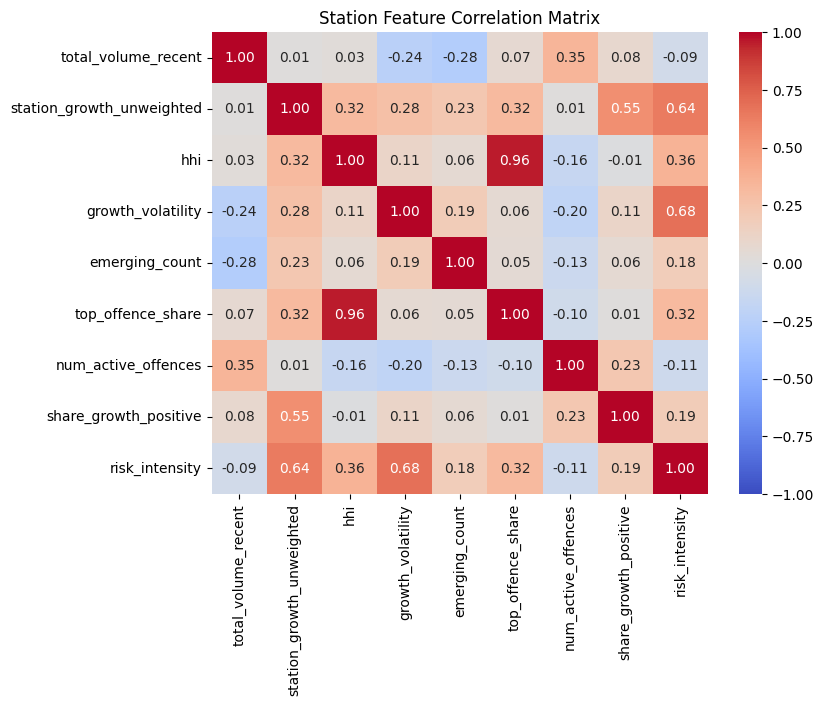

In [38]:
corr = station_features[cluster_features].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Station Feature Correlation Matrix")
plt.show()


### 🔍 Feature Correlation Analysis (Pre-Clustering Validation)

We examined the correlation structure across all engineered station-level features to ensure clustering stability.

**Key Observations:**

• `hhi` and `top_offence_share` show extremely high correlation (r = 0.96).  
  → These measure almost the same concept: offence concentration.  
  → Including both would distort KMeans distance calculations.

• `risk_intensity` moderately correlates with:
  - `growth_volatility` (r = 0.68)
  - `station_growth_unweighted` (r = 0.64)

  These are related but not redundant.

• `total_volume_recent` is largely independent of growth features.  
  → Good: scale and growth are structurally separate dimensions.

---

### 🧠 Decision

To avoid redundancy and multicollinearity in clustering:

✔ Drop `top_offence_share`  
✔ Keep `hhi` (more comprehensive concentration measure)

All other features remain.

Clustering will proceed using non-redundant dimensions.

In [39]:
cluster_features = [
    'total_volume_recent',
    'station_growth_unweighted',
    'hhi',
    'growth_volatility',
    'emerging_count',
    'num_active_offences',
    'share_growth_positive',
    'risk_intensity'
]

print(cluster_features)

['total_volume_recent', 'station_growth_unweighted', 'hhi', 'growth_volatility', 'emerging_count', 'num_active_offences', 'share_growth_positive', 'risk_intensity']


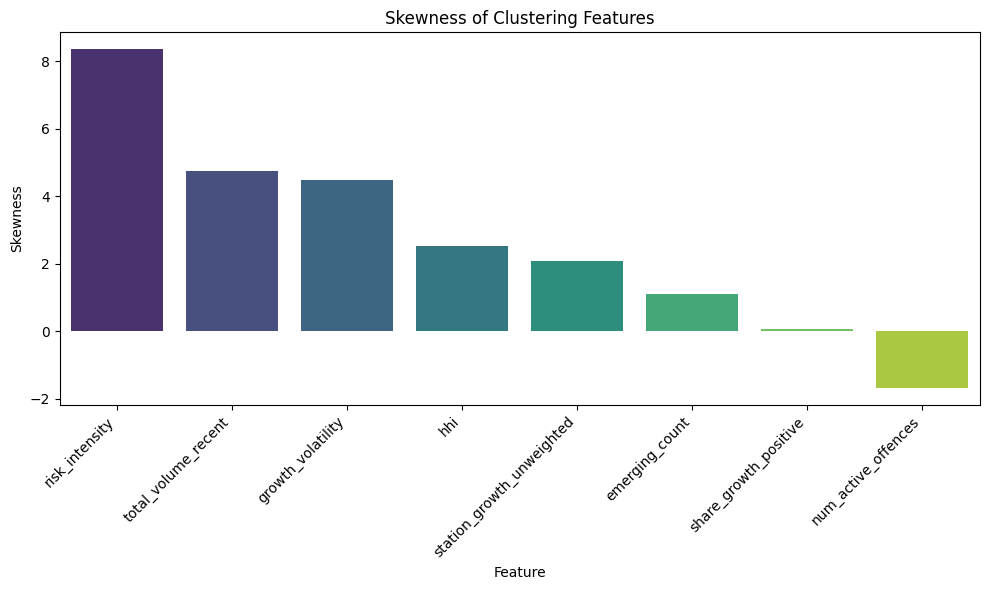

In [40]:

skew_vals = station_features[cluster_features].apply(skew).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=skew_vals.index, y=skew_vals.values, palette='viridis')
plt.title('Skewness of Clustering Features')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📊 Skewness Analysis (Pre-Clustering Diagnostics)

We evaluated skewness across all clustering features to assess distribution symmetry.

**Key Observations:**

• `risk_intensity` is extremely right-skewed (skew > 8)  
• `total_volume_recent` is heavily right-skewed (skew ≈ 4.7)  
• `growth_volatility` is also strongly right-skewed (skew ≈ 4.5)  
• `hhi` and `station_growth_unweighted` show moderate skew  
• `share_growth_positive` is nearly symmetric  
• `num_active_offences` is mildly left-skewed (acceptable)

---

### 🧠 Implication for Clustering

KMeans uses Euclidean distance and is sensitive to extreme skew.

Highly skewed features can dominate cluster formation.

---

### 🎯 Decision

Apply log transformation to:

- `total_volume_recent`
- `risk_intensity`
- `growth_volatility`

Other features can remain unchanged.

Clustering will proceed using transformed scale-stable features.

In [41]:
# Log-transform highly skewed features
station_features["log_total_volume"] = np.log1p(station_features["total_volume_recent"])
station_features["log_risk_intensity"] = np.log1p(station_features["risk_intensity"].clip(lower=0))
station_features["log_growth_volatility"] = np.log1p(station_features["growth_volatility"])

# Update clustering features (replace originals)
cluster_features = [
    "log_total_volume",
    "station_growth_unweighted",
    "hhi",
    "log_growth_volatility",
    "emerging_count",
    "num_active_offences",
    "share_growth_positive",
    "log_risk_intensity"
]

print(cluster_features)

['log_total_volume', 'station_growth_unweighted', 'hhi', 'log_growth_volatility', 'emerging_count', 'num_active_offences', 'share_growth_positive', 'log_risk_intensity']


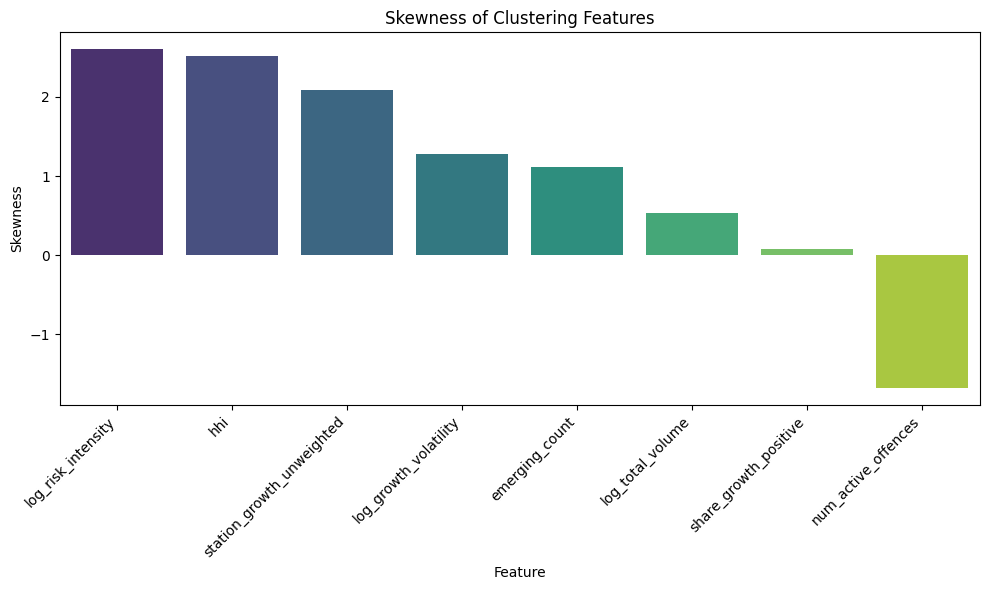

In [42]:

skew_vals = station_features[cluster_features].apply(skew).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=skew_vals.index, y=skew_vals.values, palette='viridis')
plt.title('Skewness of Clustering Features')
plt.xlabel('Feature')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

“Before clustering, I checked feature correlations and removed highly collinear variables to avoid double‑counting the same signal. I then inspected skewness and applied log‑transforms to heavily right‑skewed metrics (volume, volatility, risk intensity) so that KMeans is not dominated by a few extreme stations. The final feature set balances workload scale, growth, offence concentration, and structural change in a way that is both statistically sound and easy for Garda stakeholders to interpret.”

In [43]:
# 1) Prepare the matrix for clustering
X = station_features[cluster_features].copy()
X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) Evaluate k (3 to 7) using inertia + silhouette
k_range = range(3, 8)
inertias = []
sil_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# 3) Print a clean summary table (so you can justify k in the notebook)
print("k evaluation results (higher silhouette is better; lower inertia is better):")
for k, sil, iner in zip(k_range, sil_scores, inertias):
    print(f"k={k} | silhouette={sil:.3f} | inertia={iner:.2f}")

# Pick k using silhouette (then visually sanity-check using the plots below)
optimal_k = list(k_range)[int(np.argmax(sil_scores))]
best_sil = float(np.max(sil_scores))

print(f"\nChosen k = {optimal_k} based on the best silhouette score ({best_sil:.3f}).")



k evaluation results (higher silhouette is better; lower inertia is better):
k=3 | silhouette=0.202 | inertia=2924.91
k=4 | silhouette=0.203 | inertia=2587.86
k=5 | silhouette=0.190 | inertia=2378.87
k=6 | silhouette=0.200 | inertia=2196.67
k=7 | silhouette=0.203 | inertia=2049.48

Chosen k = 7 based on the best silhouette score (0.203).


### Choosing the number of clusters (k)

Silhouette scores are low (~0.20) across k=3–7. This is expected in this setting because:

- We are clustering **real-world stations** where profiles overlap (no “clean” boundaries).
- Features include heavy-tailed workload and mixed offence structures, which creates **continuous gradients** rather than separable blobs.
- KMeans assumes roughly spherical clusters, so it often produces lower silhouettes on complex public-sector distributions.

We observed a tie in silhouette performance between **k=4** and **k=7**, so we compared both solutions using:
- workload concentration (% of national volume per cluster),
- cluster sizes (practical interpretability),
- and narrative usability (can a planner act on the result?).


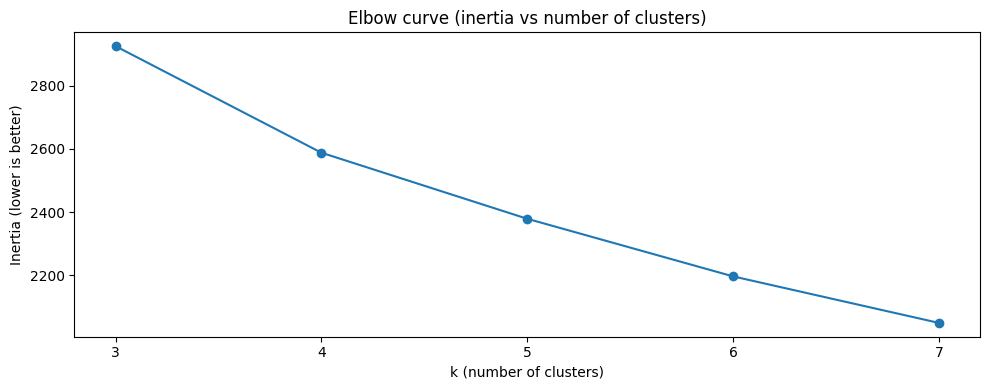

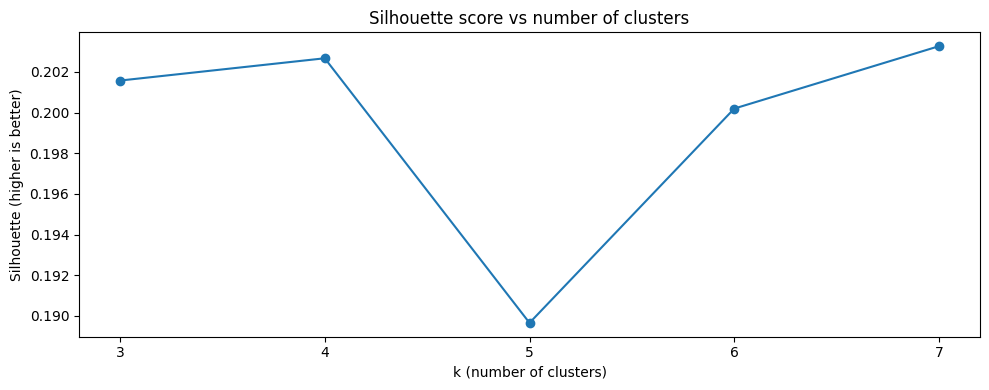

In [44]:
# 4) Visual check: elbow + silhouette curves

k_values = list(k_range)

plt.figure(figsize=(10, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow curve (inertia vs number of clusters)")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (lower is better)")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(k_values, sil_scores, marker="o")
plt.title("Silhouette score vs number of clusters")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette (higher is better)")
plt.xticks(k_values)
plt.tight_layout()
plt.show()




In [45]:
# Compare k = 4 vs k = 7 (controlled comparison)


# Use already scaled data: X_scaled

def run_kmeans(k):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    return model, labels, sil

# Run for k=4
model_4, labels_4, sil_4 = run_kmeans(4)

# Run for k=7 (for reference)
model_7, labels_7, sil_7 = run_kmeans(7)

print("Comparison")
print(f"k=4  | silhouette = {sil_4:.3f}")
print(f"k=7  | silhouette = {sil_7:.3f}")

Comparison
k=4  | silhouette = 0.203
k=7  | silhouette = 0.203


In [46]:
station_features["cluster_k4"] = labels_4
station_features["cluster_k7"] = labels_7

In [47]:
def workload_share(cluster_col):
    share = (
        station_features
        .groupby(cluster_col)["total_volume_recent"]
        .sum()
        .div(station_features["total_volume_recent"].sum())
        .mul(100)
        .round(1)
    )
    return share

print("\nWorkload share (k=4):")
print(workload_share("cluster_k4"))

print("\nWorkload share (k=7):")
print(workload_share("cluster_k7"))


Workload share (k=4):
cluster_k4
0     4.2
1     6.5
2    85.3
3     4.0
Name: total_volume_recent, dtype: float64

Workload share (k=7):
cluster_k7
0    80.4
1     4.1
2     3.6
3     0.4
4     2.7
5     6.5
6     2.4
Name: total_volume_recent, dtype: float64


In [48]:
print("\nCluster sizes (k=4):")
print(station_features["cluster_k4"].value_counts().sort_index())

print("\nCluster sizes (k=7):")
print(station_features["cluster_k7"].value_counts().sort_index())


Cluster sizes (k=4):
cluster_k4
0    150
1    192
2    184
3     38
Name: count, dtype: int64

Cluster sizes (k=7):
cluster_k7
0    156
1     33
2     28
3     40
4     71
5    143
6     93
Name: count, dtype: int64




### Final choice: k = 4

Although k=7 matches k=4 on silhouette, it fragments the station network into many smaller groups and makes the strategy story harder to communicate.  
We select **k=4** because it preserves separation while producing a simpler and more actionable set of national “strategy profiles”.

In [49]:
# 5) Fit final clustering model with chosen k=4

chosen_k = 4

final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
station_features["cluster"] = final_kmeans.fit_predict(X_scaled)

# Quick sanity check: cluster sizes
cluster_sizes = station_features["cluster"].value_counts().sort_index()
print("Cluster sizes (number of stations per cluster):")
print(cluster_sizes.to_dict())



Cluster sizes (number of stations per cluster):
{0: 150, 1: 192, 2: 184, 3: 38}


In [50]:
# 6) Statistical validation (optional but nice for credibility)


print("\nStatistical validation of clustering results")

cluster_ids = sorted(station_features["cluster"].unique())

# ANOVA: volume differs across clusters
# Use the raw volume (works fine), or use your log_total_volume if you created it earlier
vol_col = "log_total_volume" if "log_total_volume" in station_features.columns else "total_volume_recent"
groups_vol = [
    station_features.loc[station_features["cluster"] == c, vol_col].dropna().values
    for c in cluster_ids
]
_, p_val_vol = f_oneway(*groups_vol)
print(f"Volume differs by cluster (ANOVA): p-value = {p_val_vol:.5f}")

# ANOVA: growth differs across clusters
growth_col = "station_growth_unweighted"
groups_growth = [
    station_features.loc[station_features["cluster"] == c, growth_col].dropna().values
    for c in cluster_ids
]
_, p_val_growth = f_oneway(*groups_growth)
print(f"Growth differs by cluster (ANOVA): p-value = {p_val_growth:.5f}")

# Chi-square: urban vs non-urban distribution differs across clusters (validation-only)
if "urban_flag" in station_features.columns:
    ctab = pd.crosstab(station_features["cluster"], station_features["urban_flag"])
    _, p_chi, _, _ = chi2_contingency(ctab)
    print(f"Urban distribution differs by cluster (chi-square): p-value = {p_chi:.5f}")





Statistical validation of clustering results
Volume differs by cluster (ANOVA): p-value = 0.00000
Growth differs by cluster (ANOVA): p-value = 0.00000
Urban distribution differs by cluster (chi-square): p-value = 0.00000


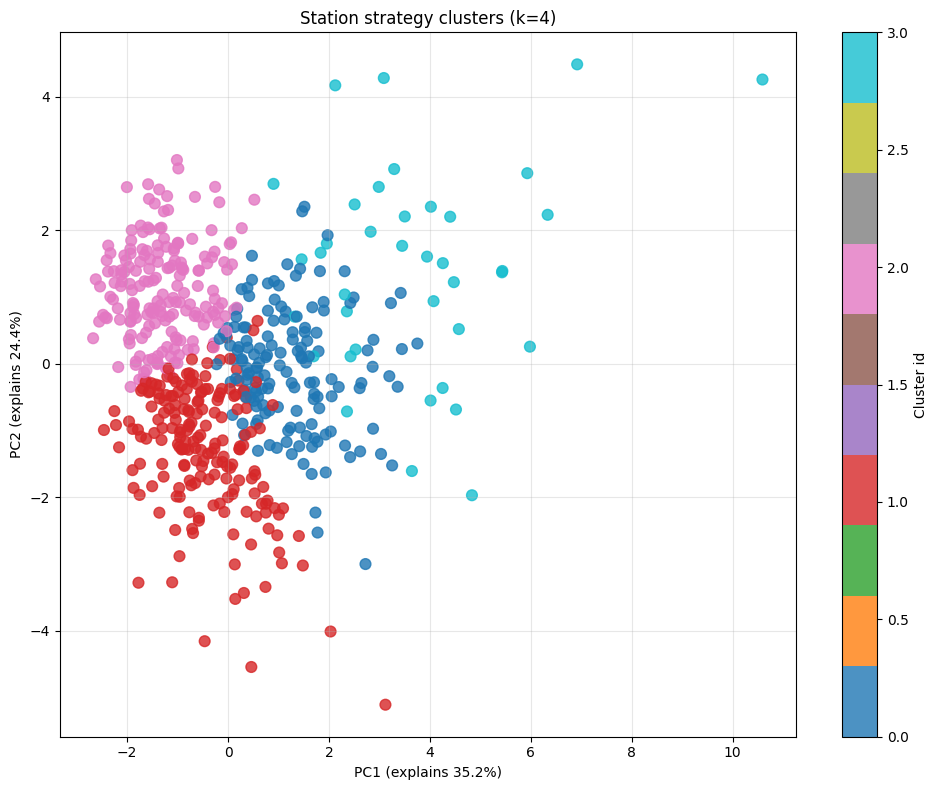

In [51]:
# 7) PCA visualisation (2D view of the clustering structure)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

station_features["pc1"] = X_pca[:, 0]
station_features["pc2"] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    station_features["pc1"],
    station_features["pc2"],
    c=station_features["cluster"],
    cmap="tab10",
    s=60,
    alpha=0.8
)
plt.xlabel(f"PC1 (explains {pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 (explains {pca.explained_variance_ratio_[1]:.1%})")
plt.title(f"Station strategy clusters (k={chosen_k})")
plt.colorbar(scatter, label="Cluster id")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()





In [52]:
# 8) Cluster profiling table (means + size + workload share)

profile = (
    station_features
    .groupby("cluster")[cluster_features + (["urban_flag"] if "urban_flag" in station_features.columns else [])]
    .mean(numeric_only=True)
    .round(3)
)

profile["n_stations"] = station_features.groupby("cluster").size()

profile["percent_national_volume"] = (
    station_features
    .groupby("cluster")["total_volume_recent"]
    .sum()
    .div(station_features["total_volume_recent"].sum())
    .mul(100)
    .round(1)
)

print("\nCluster profiles (mean features by cluster)")
display(profile)


Cluster profiles (mean features by cluster)


,log_total_volume,station_growth_unweighted,hhi,log_growth_volatility,emerging_count,num_active_offences,share_growth_positive,log_risk_intensity,urban_flag,n_stations,percent_national_volume
cluster,,,,,,,,,,,
0,5.770,0.044,0.147,0.985,1.073,12.727,0.558,0.459,0.007,150,4.2
1,5.819,-0.287,0.166,0.665,0.630,12.552,0.325,0.104,0.000,192,6.5
2,8.272,-0.085,0.150,0.493,0.223,13.826,0.503,0.092,0.207,184,85.3
3,6.441,0.636,0.288,1.146,1.158,12.579,0.543,1.207,0.053,38,4.0


In [53]:
# Assign stakeholder-friendly cluster names (k=4 solution)

cluster_names = {
    0: "Low-Volume Rural",
    1: "Emerging Growth",
    2: "National Workhorses",
    3: "Specialised Baseline"
}

# Make sure we are using the final k=4 cluster column
station_features["strategy_cluster"] = station_features["cluster"].map(cluster_names)

print("Strategy cluster distribution:")
display(station_features["strategy_cluster"].value_counts())

print("\nWorkload summary by strategy:")
display(
    station_features
    .groupby("strategy_cluster")["total_volume_recent"]
    .agg(["count", "sum", "mean"])
    .round(0)
)

Strategy cluster distribution:


,count
strategy_cluster,
Emerging Growth,192
National Workhorses,184
Low-Volume Rural,150
Specialised Baseline,38



Workload summary by strategy:


,count,sum,mean
strategy_cluster,,,
Emerging Growth,192,92457,482.0
Low-Volume Rural,150,59192,395.0
National Workhorses,184,1216593,6612.0
Specialised Baseline,38,57268,1507.0


In [54]:
# ------------------------------------------------------------
# Top 5 representative stations per strategy cluster

def top_stations_by_cluster(df, cluster_col="strategy_cluster",
                            volume_col="total_volume_recent", top_n=5):

    ordered_clusters = sorted(df[cluster_col].unique())

    for cluster_name in ordered_clusters:
        cluster_data = (
            df[df[cluster_col] == cluster_name]
            .sort_values(volume_col, ascending=False)
            .head(top_n)
        )

        print(f"\n{cluster_name} — Top {top_n} stations by workload")

        display(
            cluster_data[
                ["station_name", "station_division",
                 "total_volume_recent", "hhi", "emerging_count"]
            ].round(2)
        )


        print(f"Total stations in this group: {len(df[df[cluster_col]==cluster_name])}")
        print(f"Total workload in this group: {cluster_data[volume_col].sum():.2f}")
        print("\n")

# Call the function to display the top stations
top_stations_by_cluster(station_features, cluster_col="strategy_cluster", volume_col="total_volume_recent", top_n=5)


Emerging Growth — Top 5 stations by workload


,station_name,station_division,total_volume_recent,hhi,emerging_count
211,Blarney,Cork City,2358,0.21,0
384,Newtownmountkennedy,Wicklow,1907,0.27,0
138,Westport,Mayo,1898,0.14,0
376,Blessington,Wicklow,1785,0.14,0
351,Stradbally Co Laois,Laois/Offaly,1709,0.44,0


Total stations in this group: 192
Total workload in this group: 9657.00



Low-Volume Rural — Top 5 stations by workload


,station_name,station_division,total_volume_recent,hhi,emerging_count
87,Blackrock,Louth,1765,0.14,1
410,Carbury,Kildare,1703,0.17,1
395,Moate,Westmeath,1436,0.18,1
359,Duleek,Meath,1264,0.13,0
128,Ballyhaunis,Mayo,991,0.14,1


Total stations in this group: 150
Total workload in this group: 7159.00



National Workhorses — Top 5 stations by workload


,station_name,station_division,total_volume_recent,hhi,emerging_count
530,Store Street,D.M.R. North Central,53759,0.20,0
524,Pearse Street,D.M.R. South Central,47382,0.24,0
555,Blanchardstown,D.M.R. Western,36947,0.15,0
527,Bridewell Dublin,D.M.R. North Central,35523,0.36,0
547,Tallaght,D.M.R. Southern,33944,0.15,0


Total stations in this group: 184
Total workload in this group: 207555.00



Specialised Baseline — Top 5 stations by workload


,station_name,station_division,total_volume_recent,hhi,emerging_count
434,Nenagh,Tipperary,11071,0.41,0
536,Dublin Airport,D.M.R. Northern,8656,0.37,0
560,Rathcoole,D.M.R. Western,7418,0.23,0
360,Dunboyne,Meath,3762,0.23,0
386,Ashford,Wicklow,3259,0.46,1


Total stations in this group: 38
Total workload in this group: 34166.00




In [55]:
# Offence mix summary per cluster (optional drill-down)
offence_cluster_summary = (
    df.merge(station_features[["station_code", "strategy_cluster"]], on="station_code")
      .groupby(["strategy_cluster", "offence_group_name"])["incidents_recent"]
      .sum()
      .groupby(level=0)
      .apply(lambda x: (x / x.sum() * 100).round(1))
)

display(offence_cluster_summary.head(20))

strategy_cluster  strategy_cluster  offence_group_name                                                       
Emerging Growth   Emerging Growth   Attempts/threats to murder, assaults, harassments and related offences        9.6
                                    Burglary and related offences                                                 4.6
                                    Controlled drug offences                                                      5.6
                                    Damage to property and to the environment  offences                           7.7
                                    Dangerous or negligent acts                                                  21.2
                                    Fraud, deception and related offences                                         4.9
                                    Kidnapping and related offences                                               0.1
                                    Offences against government, justice procedures and organisation of crime     2.2
                                    Offences not elsewhere classified                                             1.3
                                    Public order and other social code offences                                   8.3
                                    Road and traffic offences                                                    22.3
                                    Robbery, extortion and hijacking offences                                     0.4
                                    Theft and related offences                                                   11.1
                                    Weapons and explosives offences                                               0.7
Low-Volume Rural  Low-Volume Rural  Attempts/threats to murder, assaults, harassments and related offences       10.6
                                    Burglary and related offences                                                 5.1
                                    Controlled drug offences                                                      4.6
                                    Damage to property and to the environment  offences                           8.5
                                    Dangerous or negligent acts                                                  18.5
                                    Fraud, deception and related offences                                         5.2
Name: incidents_recent, dtype: float64

### Final Strategic Interpretation

The segmentation identifies four structurally distinct Garda station profiles:

1. National Workhorses  
   High-volume urban hubs handling the majority of national workload.  
   Operational focus: sustained staffing scale and technology investment.

2. Emerging Growth  
   Moderate volume but structural trajectory signals.  
   Operational focus: early intervention and monitoring.

3. Low-Volume Rural  
   Stable, low-intensity stations with diversified offence mix.  
   Operational focus: maintain baseline coverage efficiency.

4. Specialised Baseline  
   Medium-volume stations with concentrated offence structures.  
   Operational focus: targeted capability development.

This segmentation enables national leadership to shift from 564 individual station plans to four differentiated strategic models.

## Part 2 — Structural Validation of Strategy Clusters

In Part 1, we segmented 564 Garda stations into four operational strategy groups
based on workload scale, growth dynamics, concentration, and structural risk signals.

Clustering alone, however, does not guarantee meaningful differentiation.
A statistically valid segmentation must also demonstrate structural differences
in crime composition.

This section evaluates whether the identified strategy clusters differ in
the types of offences they handle, not just in overall volume.

We return to the original station × offence dataset (7,896 rows) and examine:

• Offence mix within each strategy group  
• Structural patterns across clusters  
• Statistical evidence that offence composition differs by strategy  

If offence distribution varies significantly across clusters, it confirms that
the segmentation captures operationally distinct station profiles rather than
arbitrary mathematical groupings.

This step transforms clustering output into interpretable strategic insight.

### Attach strategy labels to offence-level rows

Each station has one strategy label from Part 1, but the offence dataset has 14 rows per station.
In this step, we map each station’s strategy label back onto its offence rows so we can compare offence structure across strategies.

In [56]:
# Merge strategy cluster labels back to station × offence rows
df_enriched = df.merge(
    station_features[["station_code", "strategy_cluster"]],
    on="station_code",
    how="left"
)

print("Enriched rows, columns:", df_enriched.shape)
print("Stations with missing strategy label:", df_enriched["strategy_cluster"].isna().sum())
print("\nStations per strategy:")
display(df_enriched[["station_code", "strategy_cluster"]].drop_duplicates()["strategy_cluster"].value_counts())

Enriched rows, columns: (7896, 14)
Stations with missing strategy label: 0

Stations per strategy:


,count
strategy_cluster,
Emerging Growth,192
National Workhorses,184
Low-Volume Rural,150
Specialised Baseline,38


### Quick checks after enrichment

- Enriched dataset size: 7,896 rows (564 stations × 14 offence groups), with no missing strategy labels.
- Station coverage per strategy:
  - Emerging Growth: 192 stations
  - Low-Volume Rural: 150 stations
  - National Workhorses: 184 stations
  - Specialised Baseline: 38 stations

### Offence mix within each strategy group

For each strategy group, we calculate the share of recent incidents contributed by each offence group.
This normalises away total volume and focuses only on composition (what type of crime dominates inside each strategy).

In [57]:
# Offence composition by strategy (% share of recent incidents)
strategy_totals = df_enriched.groupby("strategy_cluster")["incidents_recent"].sum()

offence_mix = (
    df_enriched
    .groupby(["strategy_cluster", "offence_group_name"])["incidents_recent"]
    .sum()
    .unstack(fill_value=0)
    .div(strategy_totals, axis=0)
    .mul(100)
)

offence_mix.round(1).style.background_gradient(cmap="YlOrRd")

offence_group_name,"Attempts/threats to murder, assaults, harassments and related offences",Burglary and related offences,Controlled drug offences,Damage to property and to the environment offences,Dangerous or negligent acts,"Fraud, deception and related offences",Kidnapping and related offences,"Offences against government, justice procedures and organisation of crime",Offences not elsewhere classified,Public order and other social code offences,Road and traffic offences,"Robbery, extortion and hijacking offences",Theft and related offences,Weapons and explosives offences
strategy_cluster,,,,,,,,,,,,,,
Emerging Growth,9.600000,4.600000,5.600000,7.700000,21.200000,4.900000,0.100000,2.200000,1.300000,8.300000,22.300000,0.400000,11.100000,0.700000
Low-Volume Rural,10.600000,5.100000,4.600000,8.500000,18.500000,5.200000,0.100000,2.500000,1.700000,8.700000,21.400000,0.500000,11.700000,0.800000
National Workhorses,7.800000,3.300000,6.900000,7.500000,10.200000,4.200000,0.100000,5.400000,0.500000,11.900000,16.800000,0.800000,23.700000,1.000000
Specialised Baseline,4.000000,2.200000,3.400000,3.400000,38.300000,2.400000,0.100000,2.300000,1.100000,12.100000,15.900000,0.200000,14.200000,0.400000


### Visual comparison (heatmap)

This heatmap shows whether strategy clusters have distinct offence “fingerprints”.
Each cell is the percentage contribution of that offence group to the cluster’s total recent incidents.

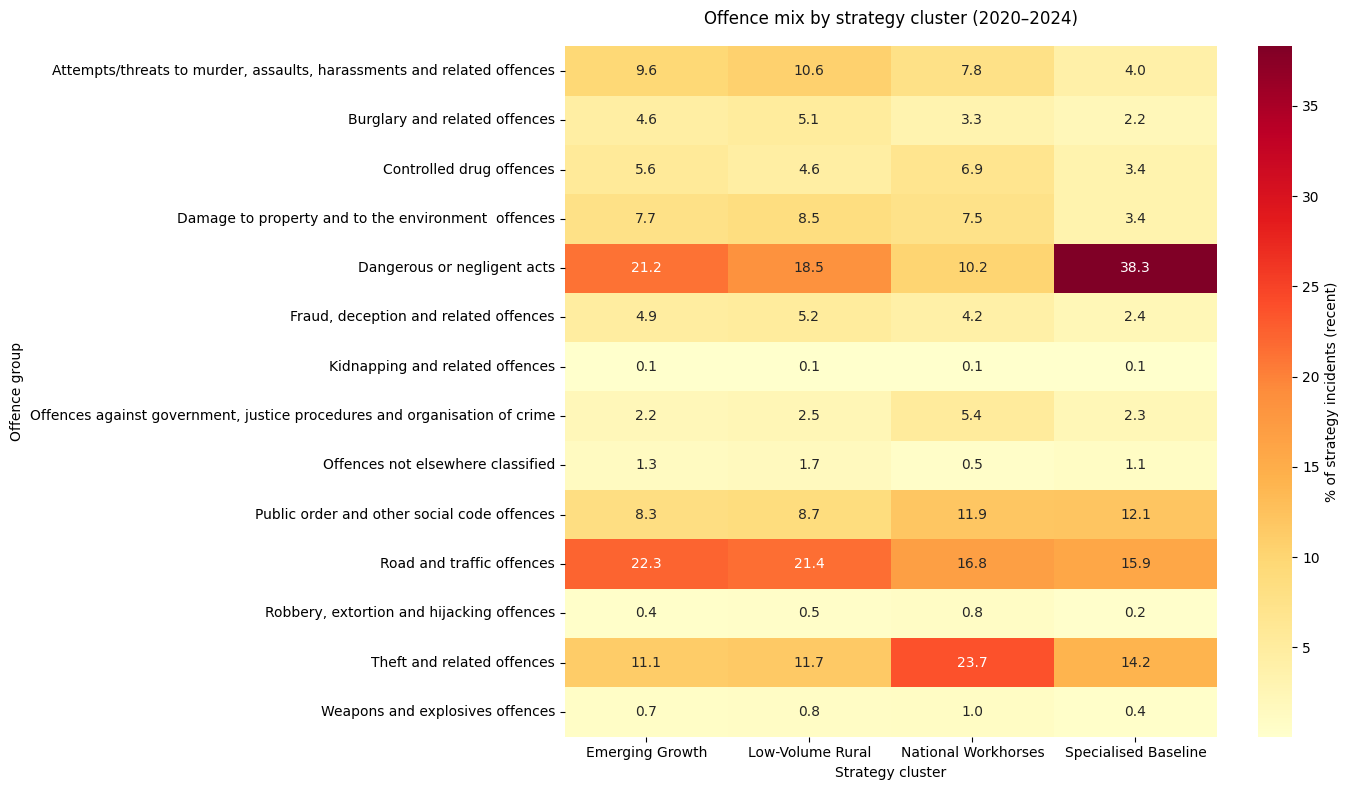

In [58]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    offence_mix.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "% of strategy incidents (recent)"}
)
plt.title("Offence mix by strategy cluster (2020–2024)", pad=16)
plt.xlabel("Strategy cluster")
plt.ylabel("Offence group")
plt.tight_layout()
plt.savefig("offence_mix_by_strategy.png", dpi=300, bbox_inches="tight")
plt.show()

### What the heatmap shows (key observations)

1) Specialised Baseline is highly dominated by "Dangerous or negligent acts" (38.3%).
   - This is a strong single-offence signature compared to every other cluster.

2) National Workhorses are theft-heavy.
   - "Theft and related offences" is the largest share (23.7%), much higher than the other clusters (~11–14%).
   - Public order is also elevated (11.9%), suggesting more complex urban-facing workload.

3) Emerging Growth and Low-Volume Rural look similar in composition.
   - Both are driven mainly by Road and traffic offences (~21–22%) and Dangerous/negligent acts (~18–21%).
   - The main separation between these two clusters is likely driven by the Part 1 features (growth behaviour / volatility), not offence mix alone.

4) Across all clusters, Road and traffic offences remain consistently large (15.9%–22.3%).
   - That makes it a national baseline workload, but its relative importance varies by station type.

### Statistical validation (Chi-square test)

Visual patterns are useful, but we also test whether offence distributions differ by strategy group beyond random variation.
The chi-square test checks whether offence type and strategy cluster are statistically associated.

In [59]:

# Use all offence groups (recommended, since there are only 14)
contingency = pd.crosstab(
    df_enriched["strategy_cluster"],
    df_enriched["offence_group_name"],
    values=df_enriched["incidents_recent"],
    aggfunc="sum"
).fillna(0)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square test results")
print(f"chi2 = {chi2_stat:.1f}")
print(f"df   = {dof}")
print(f"p    = {p_value:.6f}")

if p_value < 0.05:
    print("Result: offence composition differs across strategy clusters.")
else:
    print("Result: offence composition is not significantly different across clusters (at 5% level).")

Chi-square test results
chi2 = 71095.2
df   = 39
p    = 0.000000
Result: offence composition differs across strategy clusters.


### Statistical validation (chi-square)

Chi-square results:
- chi2 = 71095.2, df = 39, p < 0.001

Interpretation:
Offence type and strategy cluster are strongly associated.  
So the clusters are not just separating by workload/growth — they also represent different crime compositions.

### What dominates each strategy cluster?

To make the results stakeholder-friendly, we list the top offence groups inside each strategy cluster.

In [60]:
# Clean top-3 offences per strategy cluster (no NaNs)
top3_rows = []
for cluster in offence_mix.index:
    s = offence_mix.loc[cluster].sort_values(ascending=False).head(3)
    for offence, pct in s.items():
        top3_rows.append({"strategy_cluster": cluster, "offence_group_name": offence, "pct": round(pct, 1)})

top3_df = pd.DataFrame(top3_rows).sort_values(["strategy_cluster", "pct"], ascending=[True, False])
display(top3_df)

,strategy_cluster,offence_group_name,pct
0,Emerging Growth,Road and traffic offences,22.3
1,Emerging Growth,Dangerous or negligent acts,21.2
2,Emerging Growth,Theft and related offences,11.1
3,Low-Volume Rural,Road and traffic offences,21.4
4,Low-Volume Rural,Dangerous or negligent acts,18.5
5,Low-Volume Rural,Theft and related offences,11.7
6,National Workhorses,Theft and related offences,23.7
7,National Workhorses,Road and traffic offences,16.8
8,National Workhorses,Public order and other social code offences,11.9
9,Specialised Baseline,Dangerous or negligent acts,38.3


In [61]:
for cluster in offence_mix.index:
    s = offence_mix.loc[cluster].sort_values(ascending=False).head(3)
    summary = ", ".join([f"{k} ({v:.1f}%)" for k, v in s.items()])
    print(f"{cluster}: {summary}\n")

Emerging Growth: Road and traffic offences (22.3%), Dangerous or negligent acts (21.2%), Theft and related offences (11.1%)

Low-Volume Rural: Road and traffic offences (21.4%), Dangerous or negligent acts (18.5%), Theft and related offences (11.7%)

National Workhorses: Theft and related offences (23.7%), Road and traffic offences (16.8%), Public order and other social code offences (11.9%)

Specialised Baseline: Dangerous or negligent acts (38.3%), Road and traffic offences (15.9%), Theft and related offences (14.2%)



### Stakeholder-ready summaries (top offences per strategy)

- Emerging Growth: Road and traffic (22.3%), Dangerous/negligent acts (21.2%), Theft (11.1%)
- Low-Volume Rural: Road and traffic (21.4%), Dangerous/negligent acts (18.5%), Theft (11.7%)
- National Workhorses: Theft (23.7%), Road and traffic (16.8%), Public order (11.9%)
- Specialised Baseline: Dangerous/negligent acts (38.3%), Road and traffic (15.9%), Theft (14.2%)

These summaries make each strategy cluster interpretable without needing to read the full heatmap.

In [62]:
# Create stakeholder-facing master table
final_stakeholder = station_features[[
    "station_code",
    "station_name",
    "station_division",
    "county",
    "strategy_cluster",
    "total_volume_recent",
    "hhi",
    "emerging_count",
    "share_growth_positive",
    "urban_flag"
]].copy()

# Add share of national workload
total_national_volume = station_features["total_volume_recent"].sum()
final_stakeholder["percent_national_volume"] = (
    final_stakeholder["total_volume_recent"] / total_national_volume * 100
)

# Rename columns for clarity
final_stakeholder = final_stakeholder.rename(columns={
    "total_volume_recent": "recent_incidents_2020_2024",
    "hhi": "offence_concentration_index",
    "emerging_count": "emerging_offence_groups",
    "share_growth_positive": "share_offences_with_positive_growth",
    "urban_flag": "urban_station_flag"
}).round(2)

# Save
final_stakeholder.to_csv("Garda_Station_Strategy_Master.csv", index=False)

print("Saved: Garda_Station_Strategy_Master.csv")

files.download("Garda_Station_Strategy_Master.csv")

Saved: Garda_Station_Strategy_Master.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>